# Local Persistence Length Analysis for Coiled-Coil Proteins

This notebook calculates the local persistence length (L_p) of coiled coil proteins imaged using High-Speed Atomic Force Microscopy (HS-AFM).

### Methodology
- Uses a sliding window approach with a 10 nm window size
- Fits the data using the Worm-Like Chain (WLC) model
- Slide the fitting window over the entire coiled-coiled structure
- Computes time-averaged local Lp across all frames for a given configuration

### Inputs
- Traced coordinates of HS-AFM image data in specified configuration folder 
- Window size for calculating the local Lp (default: 10 nm)

### Outputs
- Representative WLC fitting plots
- Time averaged local Lp value as a function of normalized arc length for a given configuration


In [2]:
#Import required modules
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, FixedLocator
import seaborn as sns

from class_mech_gui import Filament_mech_gui
from scipy import stats

from utils import find_folder_name # Utility functions for custom naming of folder naming
from utils import do_LP_colred_SEM # Function to average local L_p over time for a given configuration

import warnings
warnings.filterwarnings("ignore")  # Suppress non-critical warnings


## Loading the data and configuring the analysis

In [3]:
# Rolling window size for local persistence length calculation (in nm)
window_size = 10.0 # in nm

# Folder path to the the traced filament coordinates of each frame stored as .csv  
folder_path_arr = ['S/1/']

# Generate configuration labels for each data folder
f_label_arr = [find_folder_name(os.path.dirname(
    f))+"_"+find_folder_name(f) for f in folder_path_arr]

## Representative WLC Fitting

(-4.0, 135.0)

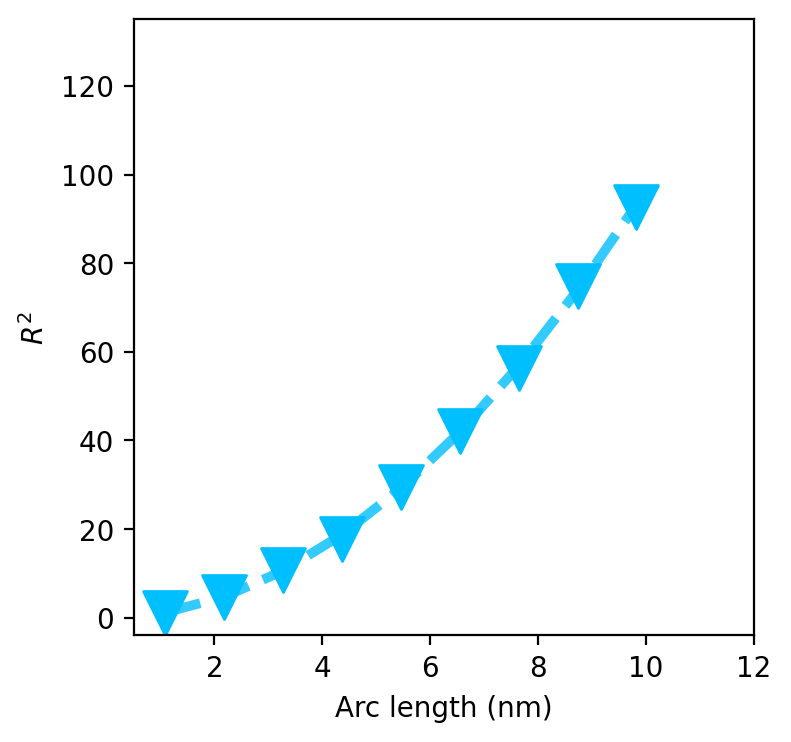

: 

In [4]:
#representative WLC fitting for to calculate the local L_p 

plt.figure(figsize=(4, 4), dpi=200)
ax = plt.gca()
S_config_obj = Filament_mech_gui(folder_path_arr[0], f_label_arr[0], num_segs=9)
# Window at 20 percent of normalized arc length of the 0 the frame of window size 10 nm 

S_config_obj.L_p_plot_poster(0.2, ax, 0, del_arc_l_nm=window_size) 

# Set axis labels and limits
ax.set_xlabel('Arc length (nm)');ax.set_ylabel('$R^2$')
ax.set_xlim(0.5, 12);ax.set_ylim(-4, 135)
ax.set_title('Representative WLC fit for local $L_p$')


## Local Persistence Length Calculation over time

In [5]:
# dataframe to store Lp results
df_lp = pd.DataFrame()

# Iterate through all data folder and compute local Lp over all frames
for i in range(len(folder_path_arr)):

    # Initialize and create an object of Filament_mech_gui class
    S_config_obj = Filament_mech_gui(folder_path_arr[i], f_label_arr[i], num_segs=9)

    # Calculate local persistence length using sliding window
    S_config_obj.roll_win_L_p_1_per_1rgn_cont(del_arc_l_nm=window_size)

    # Store results and add configuration label
    df_temp = S_config_obj.df_output
    df_temp['config_label'] = f_label_arr[i][0]
    df_lp = pd.concat([df_lp, df_temp])

# Round arc length values to 2 decimal places for consistency
df_lp = df_lp.round({ 'avg_arc_l_win_fil_1': 2})

## Plotting - Local Lp vs Normalized Arc Length

In [ ]:
# Configure plotting parameters 
plt_dict = {'font.size': 42.016808, 'lines.markersize': 14, 'figure.dpi': 300, 'lines.color': 'black',
            'xtick.major.size': 18, 'ytick.major.size': 18, 'xtick.minor.size': 12.15050424, 'ytick.minor.size': 12.15050424,
            'font.family': 'Times New Roman', 'axes.linewidth': 3,
            'xtick.major.width': 2.25, 'ytick.major.width': 2.25, 'xtick.minor.width': 1, 'ytick.minor.width': 1, 'xtick.minor.visible': True}
plt.rcParams.update(plt_dict)
plt.rcParams['figure.figsize'] = [13.206, 8.791]

# Define column names for plotting
norm_s_name = 'avg_arc_l_win_fil_1'  # Normalized arc length column
config_name = df_lp['config_label'].iloc[0]  # Configuration label

plt.figure();ax = plt.gca()

#Plot local Lp with colored SEM error bars
do_LP_colred_SEM(df_lp, norm_s_name,
                    bool_file_by_file=False, name=config_name, ax_passed=ax, plt_dict=None)

# Set axis labels and title
ax.set_xlabel("Normalised Arc Length", fontsize=plt_dict['font.size'])
ax.set_ylabel("Local L_p", fontsize=plt_dict['font.size'])
ax.set_title(file_label, fontsize=plt_dict['font.size'])

: 

: 